In [161]:
# suggested values
alpha_val = 0.9
beta_val = 0.2
small_gamma_val = 0.1
lambda_0 = 1
lambda_1 = 5

n = 10
big_T = 100

# implemeting the transition matrix gamma 

In [162]:
import numpy as np

#column 0 = serial 0
#column 1 = serial 1
#column 2 = parallel

def create_transition_matrix(gamma, beta):
    Gamma = np.array([
            [(1-gamma)  ,0          ,gamma],
            [0          ,(1-gamma)  ,gamma],
            [(beta/2)   ,(beta/2)   ,(1-beta)]
            ], dtype=float)
    return Gamma

In [163]:
test_matrix = create_transition_matrix(small_gamma_val, beta_val)
print(test_matrix)
test_matrix[2]

[[0.9 0.  0.1]
 [0.  0.9 0.1]
 [0.1 0.1 0.8]]


array([0.1, 0.1, 0.8])

# implemeting the conditional probability for Z_{t,i}

In [164]:
def p_z1_given_c(alpha, c):
    if c == 0:
        return (1-alpha)
    elif c == 1:
        return alpha 
    elif c == 2:
        return (0.5)
    else:
        raise ValueError("c must be 0, 1 or 2")

# simulation

In [165]:
def simulate_c(T, gamma, beta, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    Gamma = create_transition_matrix(gamma, beta)
    #print(Gamma)

    C = np.empty(T, dtype=int)
    C[0] =  2  #P(C_1=2)=1, just the first state

    states = np.array([0, 1, 2], dtype=int)

    for t in range(1, T):
        C[t] = rng.choice(states, p=Gamma[C[t-1]])

    return C

In [166]:
#sim_c = simulate_c(big_T, small_gamma_val, beta_val)
#sim_c

## simulate Z from C

In [167]:
def simulate_z(C, n, alpha, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    T = len(C)

    Z = np.empty((T, n), dtype=int)

    for t in range(T):
        p = p_z1_given_c(alpha, C[t])
        Z[t] = rng.binomial(n=1, p=p, size=n)

    return Z

In [168]:
#sim_z = simulate_z(sim_c, n, alpha_val)
#sim_z

## simulate X from Z

In [169]:
def simulate_x(Z, lambda_0, lambda_1, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    lam = lambda_0 + (lambda_1 - lambda_0) * Z
    X = rng.poisson(lam=lam)
    return X

In [170]:
#sim_x = simulate_x(sim_z, lambda_0, lambda_1)
#sim_x

# Full simulation of HMM

In [171]:
def simulate_hmm(T, n, alpha, beta, gamma, lambda_0, lambda_1, seed=None):
    rng = np.random.default_rng(seed)

    c = simulate_c(T=T, gamma=gamma, beta=beta, rng=rng)
    z = simulate_z(C=c, n=n, alpha=alpha, rng=rng)
    x = simulate_x(Z=z, lambda_0=lambda_0, lambda_1=lambda_1, rng=rng)

    return c, z, x 

In [172]:
C, Z, X = simulate_hmm(big_T, n, alpha_val, beta_val, small_gamma_val, lambda_0, lambda_1)

In [173]:
print(C.shape)
print(Z.shape)
print(X.shape)

(100,)
(100, 10)
(100, 10)


# Plotting

In [174]:
import matplotlib.pyplot as plt

In [175]:
def plot_single(X):
    t_vals = np.arange(1, X.shape[0]+1)

    plt.figure(figsize=(12,4))
    plt.plot(t_vals, X[:, 0], marker="o", markersize=4)
    plt.xlabel("t")
    plt.ylabel(r"$X_{t,1}$")
    plt.grid(alpha=0.6)
    plt.title("spikes count over time for neuron 1")
    plt.show()

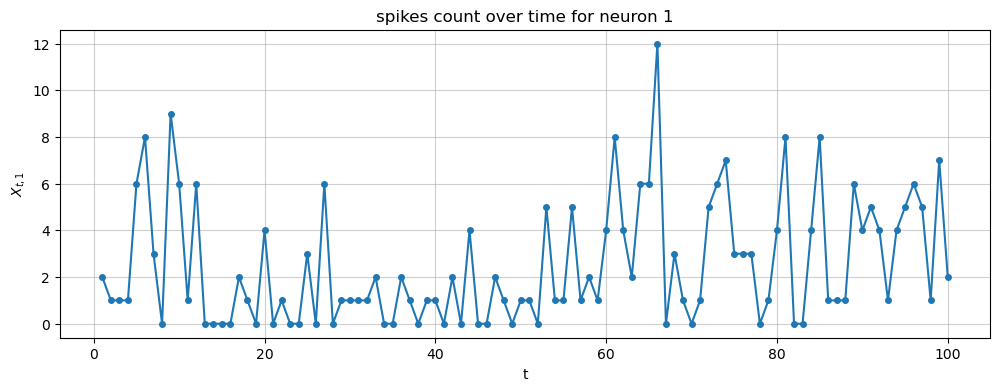

In [176]:
plot_single(X)

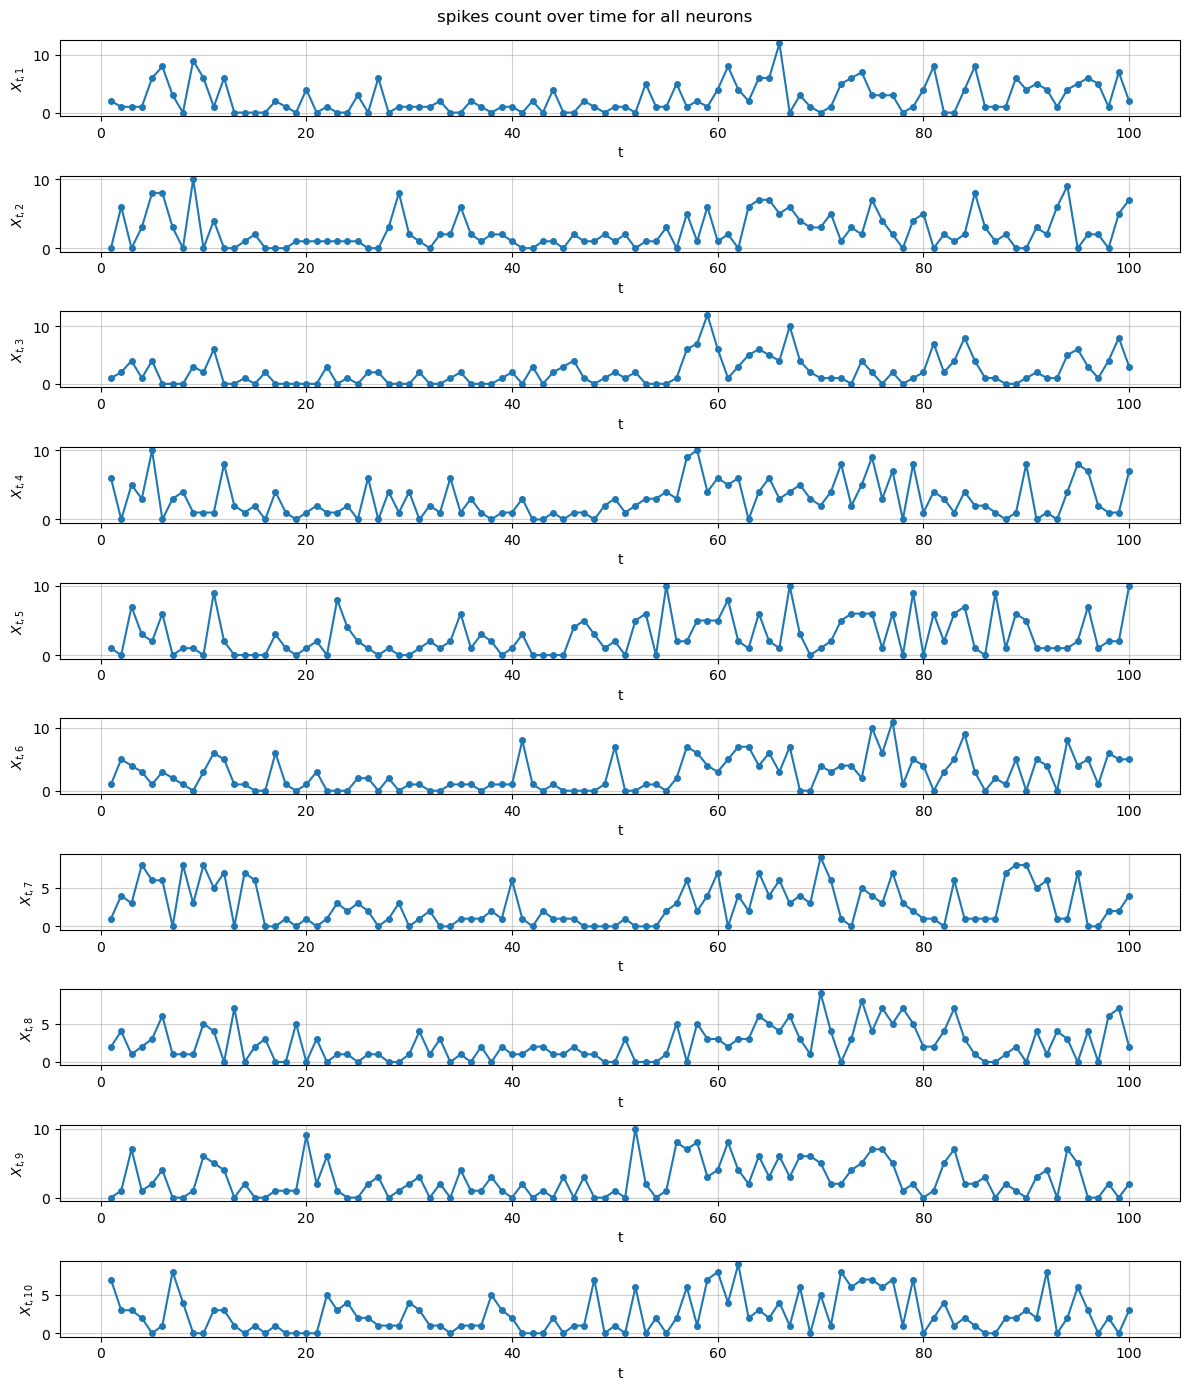

In [177]:
def plot_all(X):
    t_vals = np.arange(1, X.shape[0]+1)
    n = X.shape[1]
    fig, axes = plt.subplots(n, 1, figsize=(12, 1.4*n))
    for i in range(n):
        axes[i].plot(t_vals, X[:, i], marker="o", markersize=4)
        axes[i].set_xlabel("t")
        axes[i].set_ylabel(rf"$X_{{t,{i+1}}}$")
        axes[i].grid(alpha=0.6)
    plt.suptitle("spikes count over time for all neurons", y=0.99)
    plt.tight_layout()
    plt.show()

plot_all(X)

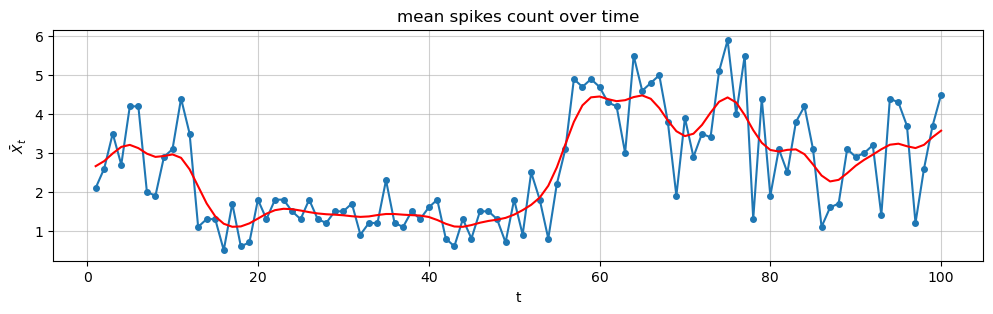

In [178]:
from scipy.ndimage import gaussian_filter1d

def plot_mean(X):
    t_vals = np.arange(1, X.shape[0] + 1)
    mean_X = X.mean(axis=1)
    smooth_mean = gaussian_filter1d(mean_X, sigma=2)

    plt.figure(figsize=(12, 3))
    plt.plot(t_vals, mean_X, marker="o", markersize=4)
    plt.plot(t_vals, smooth_mean, color="r")
    plt.xlabel("t")
    plt.ylabel(r"$\bar{X}_t$")
    plt.grid(alpha=0.6)
    plt.title("mean spikes count over time")
    plt.show()

plot_mean(X)

# multiclass logistic regression of C_t given X for one or more values of t using lots of simulated data

## make datasets

In [179]:
def make_datasets(M, t_index, T, n, alpha, beta, gamma, lambda_0, lambda_1, seed=123):
    rng = np.random.default_rng(seed)

    x_features = np.empty((M, n), dtype=float)      # one row per experiment 
    y_labels = np.empty(M, dtype=int)              # class label C_t in {0, 1, 2}

    for i in range(M):
        # simulate a new HMM sequence
        C, Z, X = simulate_hmm(T=T, n=n, alpha=alpha, beta=beta, gamma=gamma, lambda_0=lambda_0, lambda_1=lambda_1, seed=int(rng.integers(0, 10000000)))
        x_features[i] = X[t_index, :] # features are the spike counts of all neurons at time t_index
        y_labels[i] = C[t_index]     # label is the hidden state at time t_index
    
    return x_features, y_labels

## fit multiclass logistic regression

In [180]:
# first we generate the some dataset
x_features_data = []
y_labels_data = []
t_indexes = [9, 19, 29, 39, 49, 59, 69, 79, 89, 99]
for t_idx in t_indexes:
    # with seed = 123 + t_idx, we get a different dataset for each t_index
    x_features, y_labels = make_datasets(M=5000, t_index=t_idx, T=big_T, n=n, alpha=alpha_val, beta=beta_val, gamma=small_gamma_val, lambda_0=lambda_0, lambda_1=lambda_1, seed= 123 + t_idx)
    x_features_data.append(x_features)
    y_labels_data.append(y_labels)
print(x_features_data[0].shape) # feature shape: (M, n)
print(y_labels_data[0].shape)   # labels shape: (M,)
print("class counts:", np.bincount(y_labels_data[0], minlength=3))

(5000, 10)
(5000,)
class counts: [1544 1628 1828]


In [181]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x_train_data = []
x_test_data = []
y_train_data = []
y_test_data = []

for i in range(len(t_indexes)):
    x_train, x_test, y_train, y_test = train_test_split(x_features_data[i], y_labels_data[i], test_size=0.2, random_state=123)
    x_train_data.append(x_train)
    x_test_data.append(x_test)
    y_train_data.append(y_train)
    y_test_data.append(y_test)

models = []
train_errors = []
test_errors = []

for i in range(len(t_indexes)):
    model = LogisticRegression(multi_class="multinomial", max_iter=1000, random_state=123)
    model.fit(x_train_data[i], y_train_data[i])
    
    train_errors.append(1 - model.score(x_train_data[i], y_train_data[i]))
    test_errors.append(1 - model.score(x_test_data[i], y_test_data[i]))
    models.append(model)

for i in range(len(t_indexes)):
    print(f"t={t_indexes[i]+1}: train_error={train_errors[i]:.6f}, test_error={test_errors[i]:.6f}")

t=10: train_error=0.196500, test_error=0.191000
t=20: train_error=0.197000, test_error=0.171000
t=30: train_error=0.192750, test_error=0.189000
t=40: train_error=0.190500, test_error=0.210000
t=50: train_error=0.176250, test_error=0.209000
t=60: train_error=0.188250, test_error=0.166000
t=70: train_error=0.184750, test_error=0.179000
t=80: train_error=0.186250, test_error=0.204000
t=90: train_error=0.181250, test_error=0.188000
t=100: train_error=0.184000, test_error=0.203000


/Users/eske/miniconda3/envs/adl/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/eske/miniconda3/envs/adl/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/eske/miniconda3/envs/adl/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/eske/miniconda3/envs/adl/lib/python3.9/site-packages/sklearn/linear_model/_log